# Netflix Content Strategy Analysis

**Author:** Sakshi Singh  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  

---

## Objective

The goal of this project is to analyze Netflix’s content dataset to understand patterns in content distribution, growth, genres, and production countries.

This analysis aims to uncover insights into Netflix’s content strategy.

---

## Business Questions

- What type of content does Netflix prioritize?
- How has Netflix’s content library grown over time?
- Which countries contribute the most content?
- What genres dominate the platform?
- What patterns exist in movie duration and ratings?

## Dataset Description

The dataset contains information about Netflix titles, including:

- Title and type (Movie or TV Show)
- Director and cast
- Country of production
- Release year and date added
- Rating and duration
- Genres (listed categories)

This dataset is used to analyze trends and patterns in Netflix’s content library.

## IMPORT LIBRARIES

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset is loaded into a pandas DataFrame for analysis.

In [117]:
df = pd.read_csv("netflix_titles.csv")

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [118]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [119]:
df.shape

(8807, 12)

In [120]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Data Cleaning

In this step, the dataset is cleaned and prepared for analysis.  
This includes handling missing values, fixing data types, and cleaning columns such as duration.

In [122]:
# Clean date column
df["date_added"] = df["date_added"].str.strip()

# Convert to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year
df["year_added"] = df["date_added"].dt.year

## Exploratory Data Analysis

This section explores patterns in the dataset such as content distribution, country contribution, and genre trends.

### Movies vs TV Shows Distribution

This visualization shows the distribution of Movies and TV Shows available on Netflix.

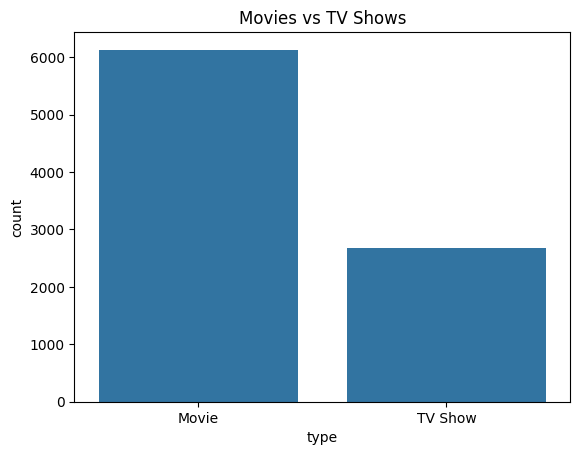

In [123]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows")
plt.show()

### Top Countries Producing Content

This analysis identifies the countries contributing the most content.

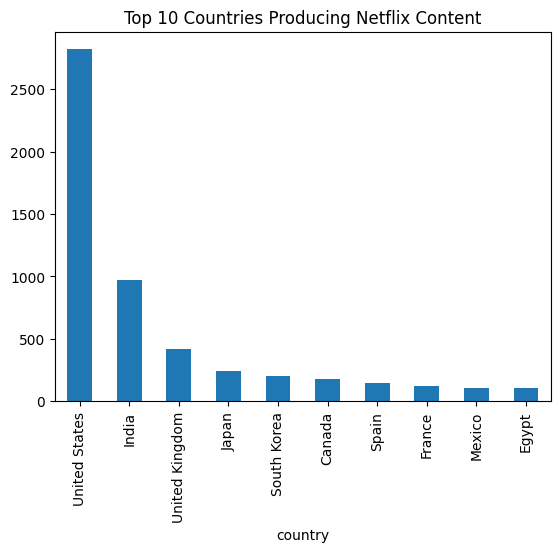

In [124]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries Producing Netflix Content")

plt.show()

Insights:

1. Netflix has significantly more movies than TV shows.
2. United States produces the highest number of titles.
3. Drama and international TV shows dominate the platform.

In [125]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

In [126]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

### Content Growth Over Years

This analysis examines how Netflix’s content library has grown over time based on release year.

In [127]:
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

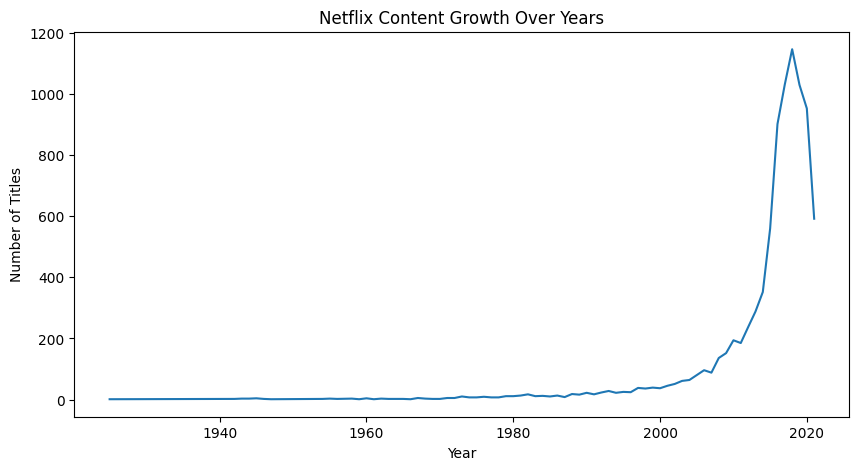

In [128]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

**Insight:**  
Netflix content increased rapidly after 2015, indicating aggressive expansion during the global streaming boom.

### Movie Duration Analysis

This analysis explores the distribution of movie durations on Netflix.

In [129]:
movies = df[df["type"] == "Movie"]

In [130]:
movies["duration"].head()

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
Name: duration, dtype: object

In [131]:
movies = df[df["type"] == "Movie"].copy()

In [132]:
#_Now analyze movie lengths._
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "")

movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

In [133]:
movies["duration"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

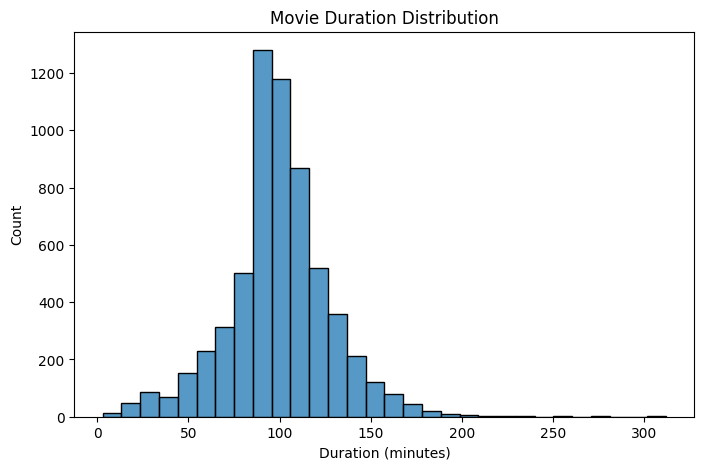

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(movies["duration"], bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")

plt.show()

**Insight:**  
Most Netflix movies are between 80–120 minutes, suggesting a standard industry duration range.

### Content Rating Distribution

This analysis examines how Netflix content is distributed across different audience ratings.

In [135]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

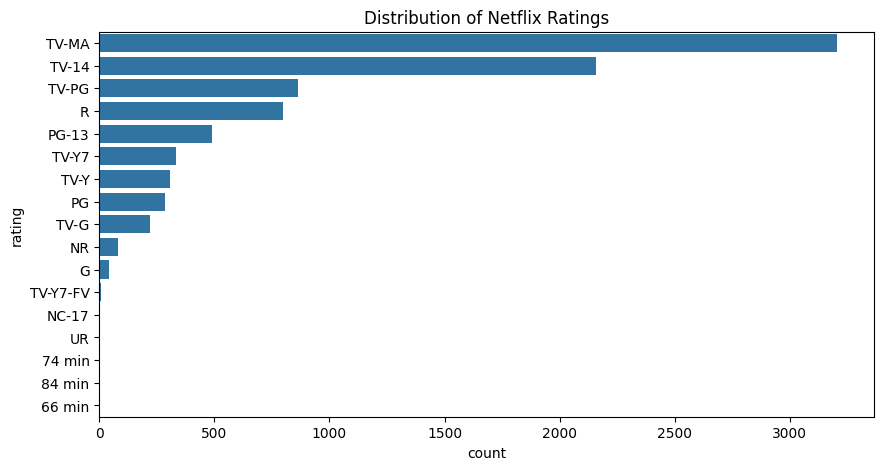

In [136]:
plt.figure(figsize=(10,5))
sns.countplot(y="rating", data=df, order=df["rating"].value_counts().index)
plt.title("Distribution of Netflix Ratings")
plt.show()

**Insight:**  
TV-MA is the most common rating, indicating that Netflix heavily targets mature audiences.

### Top Genres on Netflix

This analysis identifies the most frequent genres available on Netflix.

In [137]:
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

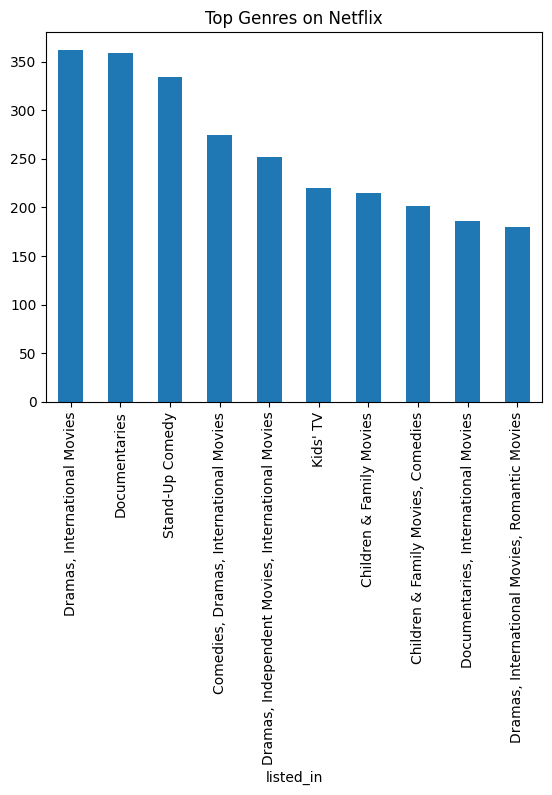

In [138]:
top_genres = df["listed_in"].value_counts().head(10)

top_genres.plot(kind="bar")
plt.title("Top Genres on Netflix")
plt.show()

**Insight:**  
Drama and international movies dominate the platform, reflecting diverse global content preferences.

### Correlation Analysis

This analysis explores relationships between numerical features such as release year, duration, and year added.

In [139]:
#_Correlation Exploration_
movies.corr(numeric_only=True)

,release_year,duration,year_added
release_year,1.000000,-0.206285,0.039285
duration,-0.206285,1.000000,0.124436
year_added,0.039285,0.124436,1.000000


**Insight:**  
There is no strong correlation between release year and duration, indicating that movie length has remained relatively stable over time.

## Advanced Analysis

This section explores deeper patterns such as content growth over time and strategic trends.

### Content Growth Over Time

This analysis examines how Netflix's content has grown over time.

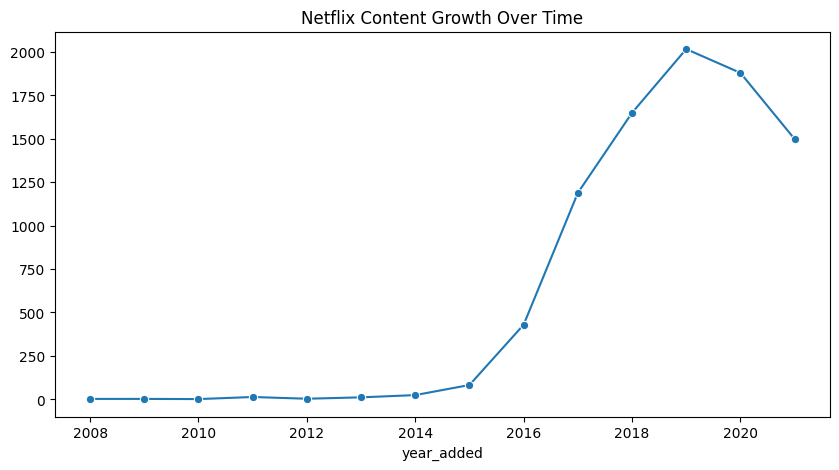

In [140]:
content_growth = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=content_growth.index, y=content_growth.values, marker="o")

plt.title("Netflix Content Growth Over Time")
plt.show()

**Insight:**  
Netflix experienced exponential growth after 2015, indicating aggressive content expansion during the global streaming boom.

## Movies vs TV Shows Trend Over Time

This analysis compares how the production of movies and TV shows has evolved over time.

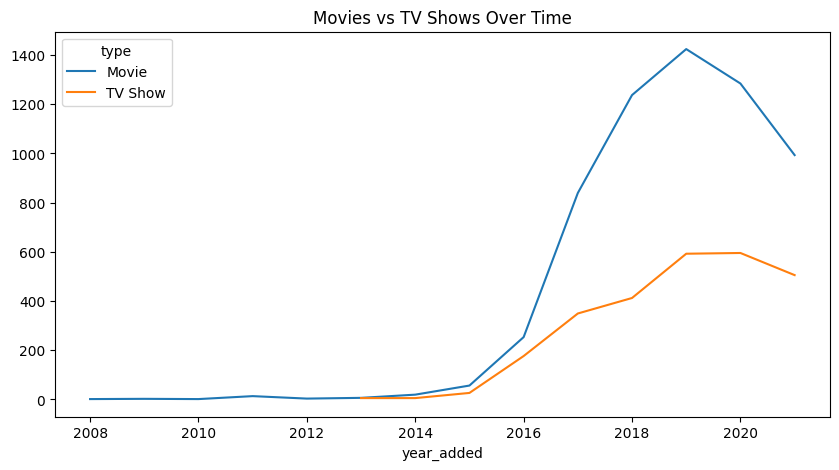

In [141]:
trend = df.groupby(["year_added","type"]).size().unstack()

trend.plot(figsize=(10,5))

plt.title("Movies vs TV Shows Over Time")
plt.show()

**Insight:**  
While movies consistently dominate Netflix’s catalog, TV shows have grown significantly after 2016. This indicates a strategic shift toward long-form content, likely driven by higher user engagement and retention.

## Country-wise Content Strategy

This analysis examines how different countries contribute to Netflix’s content production.

In [142]:
country_type = df.groupby(["country","type"]).size().unstack().fillna(0)

country_type.sort_values(by="Movie", ascending=False).head(10)

type,Movie,TV Show
country,,
United States,2058.0,760.0
India,893.0,79.0
United Kingdom,206.0,213.0
Canada,122.0,59.0
Spain,97.0,48.0
Egypt,92.0,14.0
Nigeria,86.0,9.0
Indonesia,77.0,2.0
Japan,76.0,169.0


**Insight:**  
The United States remains the largest content producer, but there is a noticeable rise in content from countries like India and the UK. This reflects Netflix’s strategy to expand globally and cater to regional audiences.

## Genre Trend Analysis

This analysis explores how different genres contribute to Netflix’s content library.

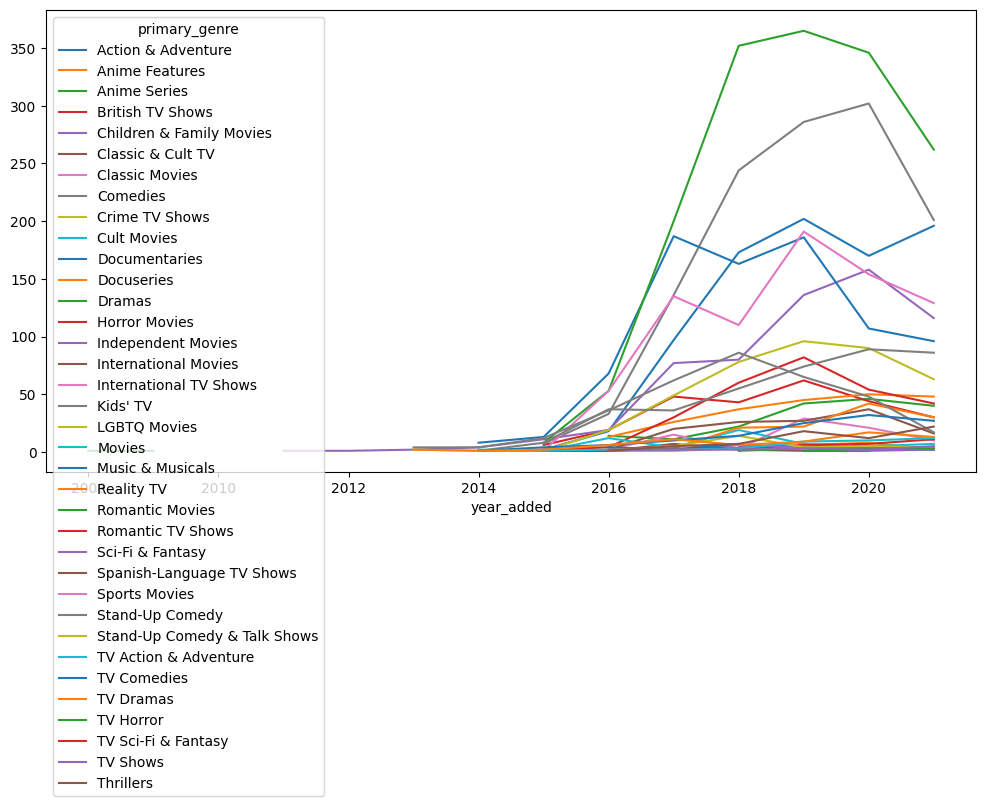

In [143]:
df["primary_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0])

genre_trend = df.groupby(["year_added","primary_genre"]).size().unstack()

genre_trend.plot(figsize=(12,6))
plt.show()

**Insight:**  
Drama and international genres dominate the platform, indicating a strong focus on globally relatable storytelling. This suggests Netflix prioritizes content that appeals to diverse cultural audiences.

### Duration Insight

**Insight:**  
Most Netflix movies fall between 80–120 minutes, aligning with standard industry practices. This suggests a strategic focus on optimal content length to maintain viewer engagement while minimizing drop-off rates.


The following insights summarize the key findings derived from the exploratory and advanced analysis.

## Key Insights

- Netflix experienced rapid content growth after 2015, indicating aggressive expansion.
- Movies dominate the platform, but TV shows are steadily increasing.
- Most movies fall between 80–120 minutes, aligning with industry standards.
- Drama and international genres are the most common.
- TV-MA is the most frequent rating, showing focus on mature audiences.

Based on the analysis, the following strategic observations can be made about Netflix’s content approach:

## Strategic Insights

- Netflix’s rapid content expansion suggests a strategy to dominate the streaming market through volume.
- The rise in TV shows indicates a shift toward long-form content to improve user retention.
- Growth in international content reflects Netflix’s focus on global market expansion.
- Standardized movie durations suggest optimization for viewer engagement.

## Limitations

- The dataset contains data only up to 2020.
- Missing values in some columns may affect analysis accuracy.
- No user engagement or watch-time data is available.
- Genre data is combined in a single column, limiting detailed analysis.

## Future Outlook

Based on the analysis, Netflix is likely to continue investing in international content and expanding its TV show library. The platform may further optimize content length and diversify genres to maintain global audience engagement.

## Conclusion

This project provides a comprehensive analysis of Netflix’s content strategy using data-driven insights.

The analysis reveals patterns in content growth, genre distribution, and audience targeting, highlighting Netflix’s focus on global expansion and engagement-driven content.

Overall, this project demonstrates the ability to extract meaningful insights from real-world datasets and translate them into business understanding.